# NIFTY50 Signal Assistant — Model Testing
**Stack:** yfinance → Feature Engineering → XGBoost → BUY/SELL/HOLD signal


In [1]:
# ── CELL 1: Imports ────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

In [2]:
# ── CELL 2: Data Download ──────────────────────────────────────────────────
# NIFTYBEES.NS = NIFTY50 ETF (tracks index closely, 5m data works reliably)
# Concat two ETFs to maximise row count (~7000-8000 rows)

TICKERS = ["NIFTYBEES.NS", "JUNIORBEES.NS"]

dfs = []
for ticker in TICKERS:
    raw = yf.download(ticker, period="60d", interval="5m", progress=False)
    if raw.empty:
        print(f"WARNING: {ticker} returned no data")
        continue
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    raw["ticker"] = ticker
    dfs.append(raw)
    print(f"{ticker}: {len(raw)} rows")

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep="first")]

print(f"\nTotal rows  : {len(df)}")
print(f"Date range  : {df.index[0]} → {df.index[-1]}")
print(f"Columns     : {list(df.columns)}")

# Need at least 3000 rows for reliable training
assert len(df) >= 3000, f"Not enough data: {len(df)} rows. Check ticker availability."

NIFTYBEES.NS: 4425 rows
JUNIORBEES.NS: 4425 rows

Total rows  : 4425
Date range  : 2026-01-16 03:45:00+00:00 → 2026-04-17 09:55:00+00:00
Columns     : ['Close', 'High', 'Low', 'Open', 'Volume', 'ticker']


In [3]:
# ── CELL 3: Indicator Calculation ─────────────────────────────────────────

# --- RSI (Wilder's EWM — standard, more accurate than simple rolling mean) ---
delta      = df["Close"].diff()
gain       = delta.clip(lower=0)
loss       = -delta.clip(upper=0)
df["rsi"]  = 100 - (100 / (1 + gain.ewm(alpha=1/14, min_periods=14).mean()
                                / loss.ewm(alpha=1/14, min_periods=14).mean()))

# --- MACD ---
df["ema_12"]    = df["Close"].ewm(span=12).mean()
df["ema_26"]    = df["Close"].ewm(span=26).mean()
df["macd"]      = df["ema_12"] - df["ema_26"]
df["macd_sig"]  = df["macd"].ewm(span=9).mean()
df["macd_hist"] = df["macd"] - df["macd_sig"]   # most predictive MACD component

# --- EMA ---
df["ema_20"]  = df["Close"].ewm(span=20).mean()
df["ema_50"]  = df["Close"].ewm(span=50).mean()
df["ema_200"] = df["Close"].ewm(span=200).mean()

# --- Bollinger Bands ---
bb_mid         = df["Close"].rolling(20).mean()
bb_std         = df["Close"].rolling(20).std()
df["bb_upper"] = bb_mid + 2 * bb_std
df["bb_lower"] = bb_mid - 2 * bb_std
df["bb_pos"]   = (df["Close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"] + 1e-9)
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / (bb_mid + 1e-9)

# --- ATR (Average True Range) ---
df["tr"]        = np.maximum(
                      df["High"] - df["Low"],
                      np.maximum(
                          abs(df["High"] - df["Close"].shift(1)),
                          abs(df["Low"]  - df["Close"].shift(1))))
df["atr"]       = df["tr"].ewm(span=14).mean()
df["atr_ratio"] = df["atr"] / df["Close"]

# --- Stochastic RSI ---
rsi_min         = df["rsi"].rolling(14).min()
rsi_max         = df["rsi"].rolling(14).max()
df["stoch_rsi"] = (df["rsi"] - rsi_min) / (rsi_max - rsi_min + 1e-9)

# --- Derived signals ---
df["ema_crossover"]   = (df["ema_20"] > df["ema_50"]).astype(int)
df["above_ema200"]    = (df["Close"]  > df["ema_200"]).astype(int)  # bull/bear regime
df["price_vs_ema20"]  = (df["Close"]  - df["ema_20"]) / df["ema_20"]
df["macd_cross"]      = ((df["macd"] > df["macd_sig"]) &
                          (df["macd"].shift(1) <= df["macd_sig"].shift(1))).astype(int)
df["rsi_trend"]       = df["rsi"] - df["rsi"].shift(3)
df["rsi_zone"]        = pd.cut(df["rsi"],
                            bins=[0, 30, 45, 55, 70, 100],
                            labels=[0, 1, 2, 3, 4]).astype(float)

# --- Volume ---
df["volume_change"]   = df["Volume"].pct_change()
df["volume_ma_ratio"] = df["Volume"] / (df["Volume"].rolling(20).mean() + 1e-9)
df["vol_spike"]       = (df["Volume"] > df["Volume"].rolling(20).mean() * 1.5).astype(int)

# --- Price action ---
df["price_change"]  = df["Close"].pct_change()
df["high_low_range"]= (df["High"] - df["Low"]) / df["Close"]
df["close_vs_open"] = (df["Close"] - df["Open"]) / df["Open"]
df["candle_body"]   = abs(df["Close"] - df["Open"]) / df["Close"]
df["upper_shadow"]  = (df["High"] - df[["Close","Open"]].max(axis=1)) / df["Close"]
df["lower_shadow"]  = (df[["Close","Open"]].min(axis=1) - df["Low"]) / df["Close"]

# --- Lag features ---
for col in ["rsi", "macd", "macd_hist", "bb_pos", "stoch_rsi"]:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag2"] = df[col].shift(2)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()
print(f"Rows after indicator calculation: {len(df)}")

Rows after indicator calculation: 4338


In [4]:
# ── CELL 4: Target Engineering ────────────────────────────────────────────
# Predict 5 candles ahead (25 mins on 5m data)
# Threshold 0.0015 = 0.15% move → aims for ~30/40/30 BUY/HOLD/SELL split

HORIZON   = 5
THRESHOLD = 0.0015

future_ret   = df["Close"].shift(-HORIZON) / df["Close"] - 1
df["target"] = np.where(future_ret >  THRESHOLD, 2,   # BUY
               np.where(future_ret < -THRESHOLD, 0,   # SELL
                                                  1))  # HOLD

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

dist = df["target"].value_counts().rename({0:"SELL", 1:"HOLD", 2:"BUY"})
total = len(df)

print("Target distribution:")
print(dist)
print(f"\nHOLD% : {dist.get('HOLD', 0)/total*100:.1f}%  (aim: 30-50%)")
print(f"BUY%  : {dist.get('BUY',  0)/total*100:.1f}%  (aim: 20-35%)")
print(f"SELL% : {dist.get('SELL', 0)/total*100:.1f}%  (aim: 20-35%)")
print()
print("Threshold guide:")
print("  HOLD% > 60% → lower THRESHOLD to 0.001")
print("  HOLD% < 20% → raise THRESHOLD to 0.002")

Target distribution:
target
SELL    1475
BUY     1466
HOLD    1397
Name: count, dtype: int64

HOLD% : 32.2%  (aim: 30-50%)
BUY%  : 33.8%  (aim: 20-35%)
SELL% : 34.0%  (aim: 20-35%)

Threshold guide:
  HOLD% > 60% → lower THRESHOLD to 0.001
  HOLD% < 20% → raise THRESHOLD to 0.002


In [5]:
# ── CELL 5: Feature List + Time-Based Split ────────────────────────────────

features = [
    # RSI
    "rsi", "rsi_lag1", "rsi_lag2", "rsi_trend", "rsi_zone",
    "stoch_rsi", "stoch_rsi_lag1",
    # MACD
    "macd", "macd_sig", "macd_hist",
    "macd_lag1", "macd_hist_lag1", "macd_hist_lag2", "macd_cross",
    # EMA / trend
    "ema_20", "ema_50", "ema_crossover", "above_ema200", "price_vs_ema20",
    # Bollinger
    "bb_pos", "bb_pos_lag1", "bb_width",
    # ATR
    "atr_ratio",
    # Volume
    "volume_change", "volume_ma_ratio", "vol_spike",
    # Price action
    "price_change", "high_low_range", "close_vs_open",
    "candle_body", "upper_shadow", "lower_shadow",
]

X = df[features]
y = df["target"]

# Time-based split — NO shuffle, NO random_state needed
split           = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Features : {len(features)}")
print(f"Train    : {len(X_train)} rows")
print(f"Test     : {len(X_test)} rows  (need ≥500 for reliable eval)")
print()
print("Train class counts:")
print(y_train.value_counts().rename({0:"SELL", 1:"HOLD", 2:"BUY"}))

Features : 32
Train    : 3470 rows
Test     : 868 rows  (need ≥500 for reliable eval)

Train class counts:
target
SELL    1182
HOLD    1163
BUY     1125
Name: count, dtype: int64


In [6]:
# ── CELL 6: Walk-Forward Cross Validation ─────────────────────────────────
# Simulates real trading: train on past, test on next window, roll forward
# Much more honest than a single 80/20 split for time-series

print("Walk-Forward CV (5 folds)")
print("-" * 40)

n_splits  = 5
fold_size = len(X) // (n_splits + 1)
fold_f1s  = []

for i in range(n_splits):
    train_end  = fold_size * (i + 1)
    test_start = train_end
    test_end   = train_end + fold_size

    X_tr = X.iloc[:train_end]
    y_tr = y.iloc[:train_end]
    X_te = X.iloc[test_start:test_end]
    y_te = y.iloc[test_start:test_end]

    sw = compute_sample_weight("balanced", y=y_tr)

    m = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        gamma=0.2,
        reg_alpha=0.5,
        reg_lambda=2.0,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
    )
    m.fit(X_tr, y_tr,
          sample_weight=sw,
          eval_set=[(X_te, y_te)],
          verbose=False)

    probs = m.predict_proba(X_te)
    preds = np.where(probs[:,2] >= 0.40, 2,
            np.where(probs[:,0] >= 0.40, 0, 1))

    f1 = f1_score(y_te, preds, average="macro", zero_division=0)
    fold_f1s.append(f1)
    print(f"  Fold {i+1}: macro_f1={f1:.4f}  |  best_iter={m.best_iteration}")

print(f"\nMean macro F1 : {np.mean(fold_f1s):.4f}")
print(f"Std macro F1  : {np.std(fold_f1s):.4f}")
print()
print("Interpretation:")
print("  High variance across folds → signal is regime-dependent")
print("  best_iter=0 in any fold    → that fold has too few samples")

Walk-Forward CV (5 folds)
----------------------------------------
  Fold 1: macro_f1=0.4860  |  best_iter=295
  Fold 2: macro_f1=0.4754  |  best_iter=307
  Fold 3: macro_f1=0.4602  |  best_iter=160
  Fold 4: macro_f1=0.5053  |  best_iter=396
  Fold 5: macro_f1=0.4519  |  best_iter=308

Mean macro F1 : 0.4758
Std macro F1  : 0.0189

Interpretation:
  High variance across folds → signal is regime-dependent
  best_iter=0 in any fold    → that fold has too few samples


In [7]:
# ── CELL 7: Final Model Training ──────────────────────────────────────────

sw_final = compute_sample_weight("balanced", y=y_train)

model = XGBClassifier(
    n_estimators=1000,         # early stopping will find the real count
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    early_stopping_rounds=40,  # stop if no improvement for 40 rounds
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    sample_weight=sw_final,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

print(f"\nBest iteration : {model.best_iteration}")
print(f"Best mlogloss  : {model.best_score:.5f}")
print()
print("mlogloss guide:")
print("  Random baseline = 1.099 (log(3))")
print("  < 1.05 → model is learning real patterns")
print("  1.05-1.08 → weak signal, add more features")
print("  > 1.08 → near random, check data quality")

[0]	validation_0-mlogloss:1.09602
[100]	validation_0-mlogloss:0.96354
[200]	validation_0-mlogloss:0.93895
[282]	validation_0-mlogloss:0.93783

Best iteration : 242
Best mlogloss  : 0.93724

mlogloss guide:
  Random baseline = 1.099 (log(3))
  < 1.05 → model is learning real patterns
  1.05-1.08 → weak signal, add more features
  > 1.08 → near random, check data quality


In [8]:
# ── CELL 8: Asymmetric Threshold Sweep ────────────────────────────────────
# Separate BUY and SELL thresholds — they don't need to be the same

probs   = model.predict_proba(X_test)
results = []

print("Threshold sweep (macro F1):")
print(f"{'BUY_t':>6} {'SELL_t':>7} {'macro_f1':>9}")
print("-" * 26)

for bt in np.arange(0.30, 0.60, 0.05):
    for st in np.arange(0.30, 0.60, 0.05):
        p  = np.where(probs[:,2] >= bt, 2,
             np.where(probs[:,0] >= st, 0, 1))
        f1 = f1_score(y_test, p, average="macro", zero_division=0)
        results.append((round(bt, 2), round(st, 2), round(f1, 4)))

# Show top 5
for bt, st, f1 in sorted(results, key=lambda x: -x[2])[:5]:
    print(f"{bt:>6.2f} {st:>7.2f} {f1:>9.4f}")

best = max(results, key=lambda x: x[2])
BUY_THRESH = best[0]
SEL_THRESH = best[1]
print(f"\nBest → BUY≥{BUY_THRESH}  SELL≥{SEL_THRESH}  macro_f1={best[2]}")

Threshold sweep (macro F1):
 BUY_t  SELL_t  macro_f1
--------------------------
  0.55    0.45    0.5121
  0.55    0.30    0.5074
  0.55    0.35    0.5074
  0.55    0.40    0.5058
  0.55    0.50    0.5036

Best → BUY≥0.55  SELL≥0.45  macro_f1=0.5121


In [9]:
# ── CELL 9: Evaluation ────────────────────────────────────────────────────

preds = np.where(probs[:,2] >= BUY_THRESH, 2,
        np.where(probs[:,0] >= SEL_THRESH, 0, 1))

print("=" * 55)
print(f"Accuracy  : {accuracy_score(y_test, preds):.4f}  (ignore — biased by HOLD)")
print("=" * 55)
print(classification_report(
    y_test, preds,
    target_names=["SELL", "HOLD", "BUY"],
    zero_division=0
))

print("What to target:")
print("  SELL recall > 0.40")
print("  BUY  recall > 0.40")
print("  HOLD precision > 0.70")
print("  Macro F1 > 0.50")

Accuracy  : 0.5622  (ignore — biased by HOLD)
              precision    recall  f1-score   support

        SELL       0.57      0.86      0.68       293
        HOLD       0.37      0.20      0.26       234
         BUY       0.64      0.55      0.59       341

    accuracy                           0.56       868
   macro avg       0.53      0.54      0.51       868
weighted avg       0.54      0.56      0.53       868

What to target:
  SELL recall > 0.40
  BUY  recall > 0.40
  HOLD precision > 0.70
  Macro F1 > 0.50


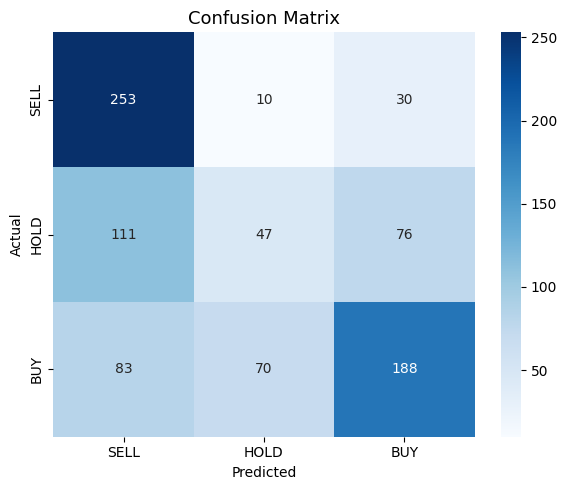

In [10]:
# ── CELL 10: Confusion Matrix ─────────────────────────────────────────────

cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["SELL", "HOLD", "BUY"],
            yticklabels=["SELL", "HOLD", "BUY"],
            cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

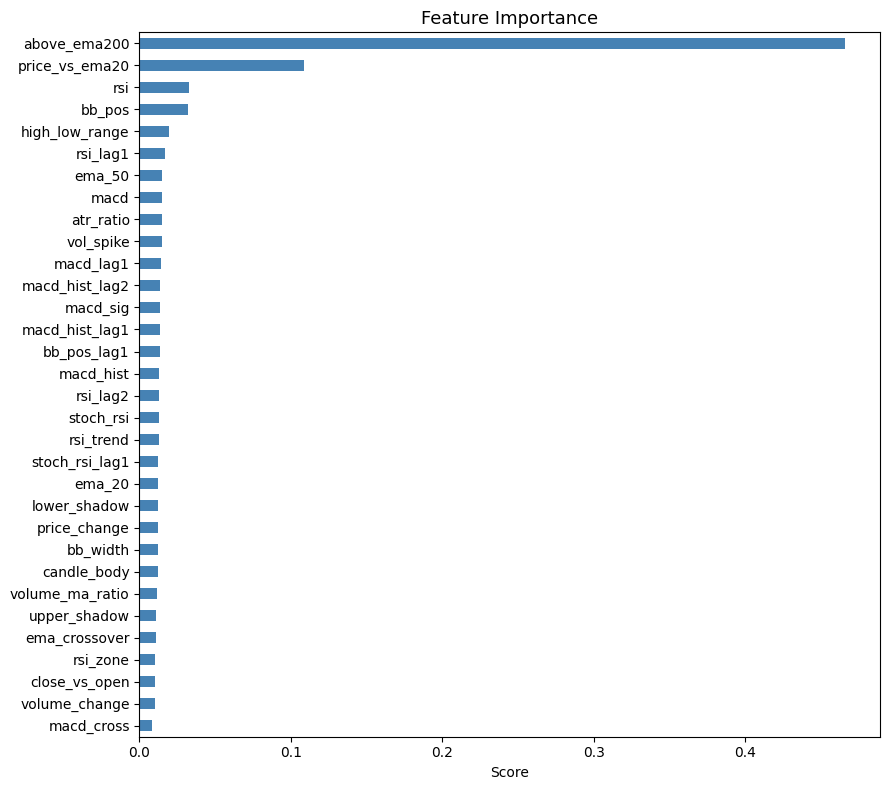


Low importance features (consider dropping): ['macd_cross']


In [11]:
# ── CELL 11: Feature Importance ───────────────────────────────────────────

imp = pd.Series(model.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance", fontsize=13)
ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

# Drop features with near-zero importance
low_imp = imp[imp < 0.01].index.tolist()
if low_imp:
    print(f"\nLow importance features (consider dropping): {low_imp}")
else:
    print("\nAll features contributing meaningfully.")

In [12]:
# ── CELL 12: Live Signal on Latest Candle ────────────────────────────────

latest     = X_test.iloc[[-1]]
live_probs = model.predict_proba(latest)[0]
sell_p, hold_p, buy_p = live_probs

signal = ("BUY"  if buy_p  >= BUY_THRESH else
          "SELL" if sell_p >= SEL_THRESH else
          "HOLD")

emoji  = {"BUY": "🟢", "SELL": "🔴", "HOLD": "🟡"}

print(f"{emoji[signal]} Signal  : {signal}")
print(f"   BUY   : {buy_p:.3f}  (threshold ≥ {BUY_THRESH})")
print(f"   HOLD  : {hold_p:.3f}")
print(f"   SELL  : {sell_p:.3f}  (threshold ≥ {SEL_THRESH})")
print(f"\nTimestamp : {X_test.index[-1]}")

🟢 Signal  : BUY
   BUY   : 0.562  (threshold ≥ 0.55)
   HOLD  : 0.237
   SELL  : 0.200  (threshold ≥ 0.45)

Timestamp : 2026-04-17 09:55:00+00:00


In [13]:
# ── CELL 13: AgentState dict (for LangGraph integration) ──────────────────
# This is what your agent/state.py AgentState will carry

agent_state = {
    "symbol"          : "NIFTYBEES.NS",
    "timestamp"       : str(X_test.index[-1]),
    "features"        : latest.to_dict(orient="records")[0],
    "probabilities"   : {
        "SELL" : round(float(sell_p), 4),
        "HOLD" : round(float(hold_p), 4),
        "BUY"  : round(float(buy_p),  4),
    },
    "signal"          : signal,
    "confidence"      : round(float(max(sell_p, hold_p, buy_p)), 4),
    "sentiment_score" : 0.0,   # ← FinBERT output goes here
    "reasoning"       : "",    # ← LLM explanation goes here
}

import json
print(json.dumps(
    {k: v for k, v in agent_state.items() if k != "features"},
    indent=2
))

{
  "symbol": "NIFTYBEES.NS",
  "timestamp": "2026-04-17 09:55:00+00:00",
  "probabilities": {
    "SELL": 0.2004,
    "HOLD": 0.2372,
    "BUY": 0.5624
  },
  "signal": "BUY",
  "confidence": 0.5624,
  "sentiment_score": 0.0,
  "reasoning": ""
}
